In [4]:
pip install yfinance


Note: you may need to restart the kernel to use updated packages.


In [5]:
import yfinance as yf
ticker = 'TSLA'
history = yf.download(ticker,start='2020-1-1' , end='2025-1-1')
print(history.info())
print(history.head())

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1258 non-null   float64
 1   (High, TSLA)    1258 non-null   float64
 2   (Low, TSLA)     1258 non-null   float64
 3   (Open, TSLA)    1258 non-null   float64
 4   (Volume, TSLA)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB
None
Price           Close       High        Low       Open     Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                             
2020-01-02  28.684000  28.713333  28.114000  28.299999  142981500
2020-01-03  29.534000  30.266666  29.128000  29.366667  266677500
2020-01-06  30.102667  30.104000  29.333332  29.364668  151995000
2020-01-07  31.270666  31.441999  30.224001  30.760000  268231500
2020-01-08  32.809334  33.232666  31.215334

In [6]:
import pandas as pd
df = pd.DataFrame(history)
print(df)

Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2020-01-02   28.684000   28.713333   28.114000   28.299999  142981500
2020-01-03   29.534000   30.266666   29.128000   29.366667  266677500
2020-01-06   30.102667   30.104000   29.333332   29.364668  151995000
2020-01-07   31.270666   31.441999   30.224001   30.760000  268231500
2020-01-08   32.809334   33.232666   31.215334   31.580000  467164500
...                ...         ...         ...         ...        ...
2024-12-24  462.279999  462.779999  435.140015  435.899994   59551800
2024-12-26  454.130005  465.329987  451.019989  465.160004   76366400
2024-12-27  431.660004  450.000000  426.500000  449.519989   82666800
2024-12-30  417.410004  427.000000  415.750000  419.399994   64941000
2024-12-31  403.839996  427.929993  402.540009  423.790009   76825100

[1258 rows x 5 colu

In [7]:
import numpy as np
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan , strategy = 'mean')
data = df[["Open","High","Low","Close","Volume"]].values
print("data with missing values:")
df.info()
print(df.isnull().sum())
print(data)
imputer = imputer.fit(data)
clean_data = imputer.transform(data)
print("data without missing values")
print(clean_data)



data with missing values:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1258 non-null   float64
 1   (High, TSLA)    1258 non-null   float64
 2   (Low, TSLA)     1258 non-null   float64
 3   (Open, TSLA)    1258 non-null   float64
 4   (Volume, TSLA)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB
Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64
[[2.82999992e+01 2.87133331e+01 2.81140003e+01 2.86840000e+01
  1.42981500e+08]
 [2.93666668e+01 3.02666664e+01 2.91280003e+01 2.95340004e+01
  2.66677500e+08]
 [2.93646679e+01 3.01040001e+01 2.93333321e+01 3.01026669e+01
  1.51995000e+08]
 ...
 [4.49519989e+02 4.50000000e+02 4.26500000e+02 4.31660004e+02
  8.26668000e+07]
 [4.19399994e+02 4.27000000e+02

In [8]:
drop = df.drop(columns = 'Close')
target = df['Close'].shift(-1)
print(target)

Ticker            TSLA
Date                  
2020-01-02   29.534000
2020-01-03   30.102667
2020-01-06   31.270666
2020-01-07   32.809334
2020-01-08   32.089333
...                ...
2024-12-24  454.130005
2024-12-26  431.660004
2024-12-27  417.410004
2024-12-30  403.839996
2024-12-31         NaN

[1258 rows x 1 columns]


In [10]:
from sklearn.model_selection import train_test_split
X = df[["Open","High" ,"Low","Volume"]].values
y = df["Close"].shift(-1).values
X = X[:-1]
y = y[:-1]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2 , train_size = 0.8 , random_state = 42)
print(f"training samples:{X_train.shape[0]}")
print(f"testing samples:{X_test.shape[0]}")


training samples:1005
testing samples:252


In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)
prediction = model.predict(X_test)
print(prediction)

[[251.00797399]
 [ 56.20807204]
 [ 29.92944202]
 [ 32.38801483]
 [173.20322582]
 [252.38437702]
 [185.96614266]
 [277.22281814]
 [346.4539864 ]
 [187.48196315]
 [246.5859349 ]
 [180.40978971]
 [154.64294489]
 [179.20877963]
 [171.15227066]
 [209.63409314]
 [234.30802069]
 [163.82698124]
 [212.13085565]
 [265.78527122]
 [234.10000432]
 [192.41086669]
 [139.2126573 ]
 [243.67475973]
 [208.71518106]
 [193.90247191]
 [248.86955409]
 [285.86718017]
 [403.93653079]
 [ 51.0268121 ]
 [189.83328443]
 [244.25745507]
 [237.20777285]
 [302.88745247]
 [197.75646581]
 [236.99902867]
 [212.33110618]
 [194.00912995]
 [163.97811581]
 [149.34973734]
 [249.39080387]
 [224.1957697 ]
 [221.15811123]
 [ 67.49643484]
 [253.5578958 ]
 [210.5191597 ]
 [275.58979559]
 [ 49.17146345]
 [263.71616285]
 [245.59920693]
 [281.20217524]
 [244.97463481]
 [251.58397076]
 [267.50044824]
 [197.6010152 ]
 [216.99867854]
 [137.77616961]
 [125.67228263]
 [257.59587146]
 [230.31154458]
 [246.7007518 ]
 [228.13533321]
 [239.38

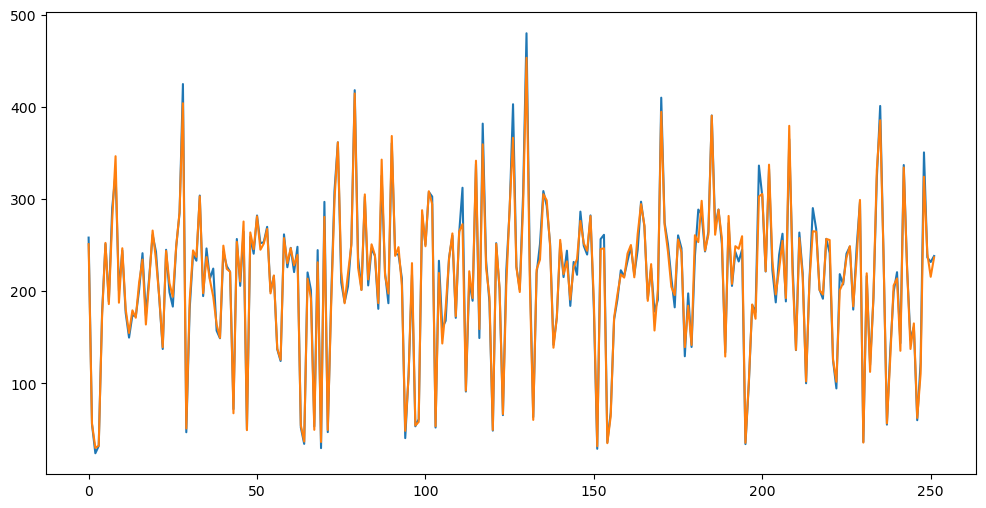

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,6))
plt.plot(y_test)
plt.plot(prediction)
plt.show()